# EDA

## 1. Import libraries and load the dataset

In [1]:
# Import pandas for working with tables/data
import pandas as pd

# Import matplotlib for creating charts
import matplotlib.pyplot as plt

# Keep the same colors for the two stock-status groups
COLORS = {'overstock': '#2a78b6', 'stockout': '#e74c3c'}

# Location of our cleaned CSV dataset
CLEAN_DATASET = '../data/cleaned_stock_risk_prediction_dataset.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(CLEAN_DATASET)

# Show the first 5 rows to check that the data loaded correctly
df.head()


,current_stock,avg_daily_demand,lead_time_days,reorder_point,sales_last_30_days,stock_turnover_ratio,forecast_error,season,item_category,supplier_reliability,stock_status
0,549,45.76,5.64,342.83,1604.49,4.17,-9.90,peak,essential,low,overstock
1,486,45.47,6.39,348.37,1585.00,4.01,-5.27,peak,non-essential,high,overstock
2,564,32.04,5.81,353.21,1219.04,3.57,-2.94,off-peak,non-essential,high,overstock
3,652,46.70,7.22,397.34,1673.88,4.00,0.75,off-peak,essential,low,overstock
4,476,57.33,9.39,312.64,1052.98,4.49,5.12,peak,essential,high,overstock


## 2. Check the size and structure of the data

In [2]:
# Print the number of rows and columns
print("Rows and columns:", df.shape)

print()

# Show column names, data types, and non-empty values
df.info()


Rows and columns: (5000, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   current_stock         5000 non-null   int64  
 1   avg_daily_demand      5000 non-null   float64
 2   lead_time_days        5000 non-null   float64
 3   reorder_point         5000 non-null   float64
 4   sales_last_30_days    5000 non-null   float64
 5   stock_turnover_ratio  5000 non-null   float64
 6   forecast_error        5000 non-null   float64
 7   season                5000 non-null   object 
 8   item_category         5000 non-null   object 
 9   supplier_reliability  5000 non-null   object 
 10  stock_status          5000 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 429.8+ KB


## 3. Understand the stock-status distribution

Here we check how many records belong to each `stock_status`.

The possible groups are:

- **overstock** → more stock than needed
- **stockout** → not enough stock

We calculate both the **number** and **percentage** of records in each group.

The bar chart makes the comparison easier to see.

stock_status
overstock    4543
stockout      457
Name: count, dtype: int64

stock_status
overstock    90.9 %
stockout      9.1 %
Name: count, dtype: object


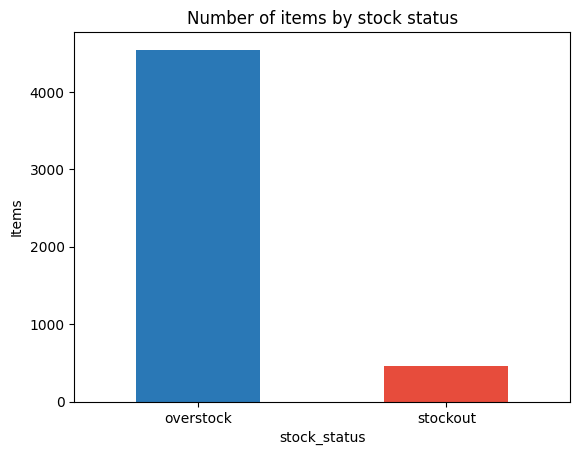

In [3]:
# Count how many records are in each stock-status group
counts = df['stock_status'].value_counts()

print(counts)
print()

# Convert the counts into percentages
print((counts / len(df) * 100).round(1).astype(str) + " %")

# Create a bar chart to compare the number of records
counts.plot(
    kind="bar",
    color=[COLORS[c] for c in counts.index],
    rot=0
)

plt.title("Number of items by stock status")
plt.ylabel("Items")
plt.show()


## 4. Look at the distribution of numeric columns

A histogram shows how values are spread out.

For example:

- How much current stock is common?
- What is the usual daily demand?
- What values do we see for lead time?

We create one histogram for each important numeric column.

`bins=30` divides the values into 30 small ranges.

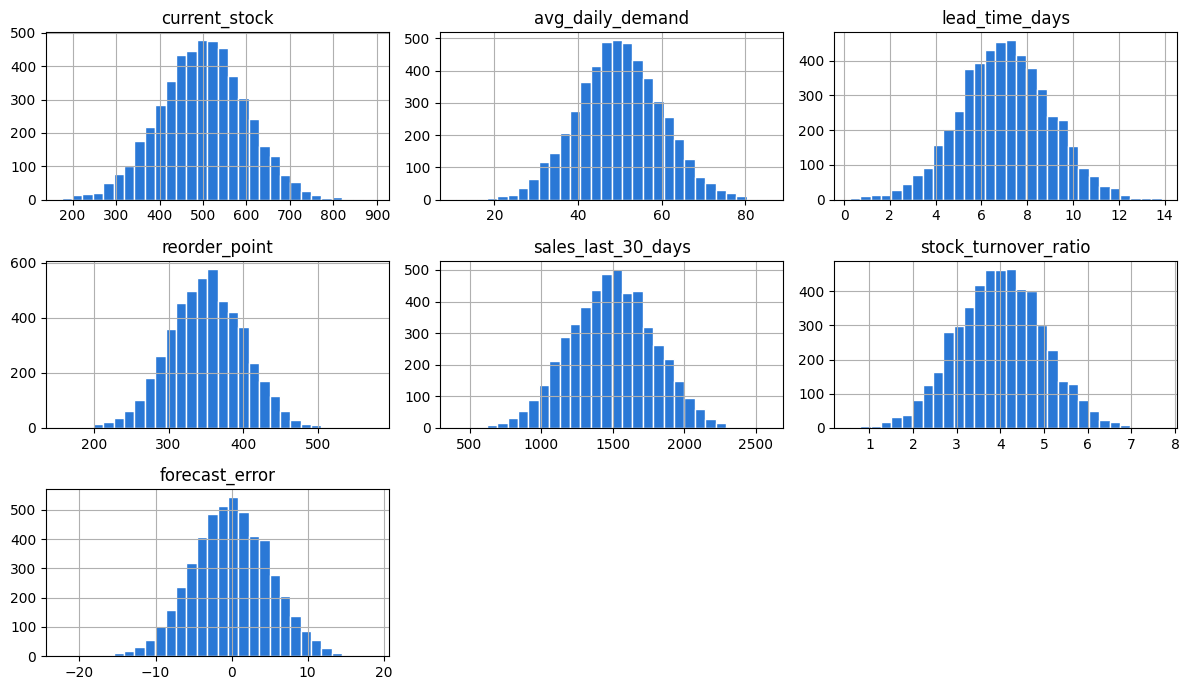

In [4]:
# Select the numeric columns we want to study
numeric_cols = [
    "current_stock",
    "avg_daily_demand",
    "lead_time_days",
    "reorder_point",
    "sales_last_30_days",
    "stock_turnover_ratio",
    "forecast_error"
]

# Create a histogram for each numeric column
# Histograms help us see how the values are distributed
df[numeric_cols].hist(
    bins=30,
    figsize=(12, 7),
    color="#2a78d6",
    edgecolor="white"
)

plt.tight_layout()
plt.show()


## 5. Get basic statistics

`describe()` gives us a quick statistical summary for the numeric columns.

In [5]:
# Show common statistics for every numeric column
# round(2) keeps the output easier to read
df[numeric_cols].describe().round(2)


,current_stock,avg_daily_demand,lead_time_days,reorder_point,sales_last_30_days,stock_turnover_ratio,forecast_error
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,500.07,49.90,7.02,350.83,1494.49,3.99,-0.05
std,99.65,10.10,2.00,50.17,295.01,1.00,5.13
min,175.00,10.78,0.25,157.18,403.47,0.55,-22.33
25%,434.00,43.13,5.68,316.76,1289.47,3.30,-3.54
50%,501.00,49.82,7.02,350.96,1497.59,4.00,-0.12
75%,566.00,56.77,8.35,385.33,1695.18,4.68,3.44
max,892.00,85.29,13.86,573.95,2583.41,7.69,18.64


## 6. Compare numeric values by stock status

Now we compare the average value of every numeric feature for:

- `overstock`
- `stockout`

In [6]:
# Group the data by stock status
# Then calculate the average of each numeric feature
# .T transposes the table so the features appear as rows
df.groupby("stock_status")[numeric_cols].mean().round(2).T


stock_status,overstock,stockout
current_stock,516.32,338.51
avg_daily_demand,49.89,50.01
lead_time_days,7.03,6.96
reorder_point,346.65,392.34
sales_last_30_days,1495.41,1485.37
stock_turnover_ratio,3.99,4.07
forecast_error,-0.04,-0.25


## 7. Compare the groups using boxplots

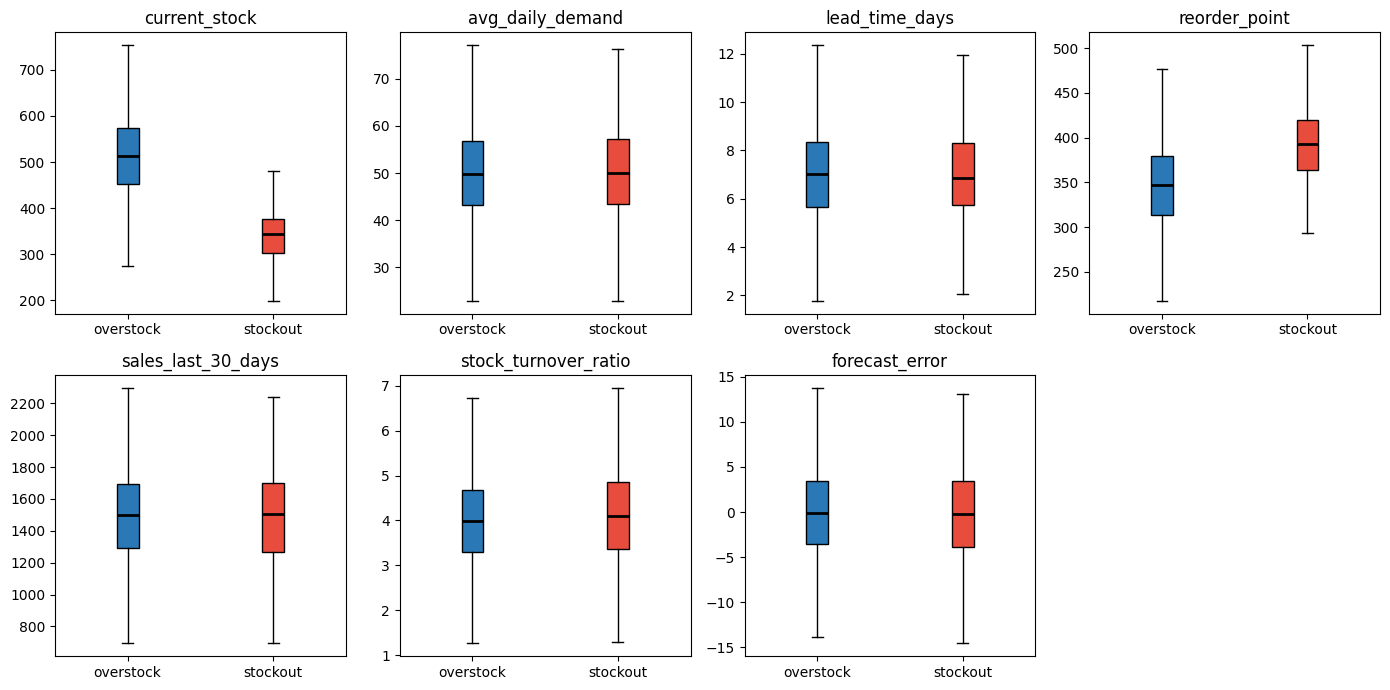

In [7]:
# Create a grid of boxplots
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Create one boxplot for each numeric column
for ax, col in zip(axes.flat, numeric_cols):

    # Get the values separately for overstock and stockout
    groups = [
        df.loc[df["stock_status"] == s, col]
        for s in ["overstock", "stockout"]
    ]

    # Draw the two boxplots
    box = ax.boxplot(
        groups,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 2}
    )

    # Give each group its matching color
    for patch, s in zip(box["boxes"], ["overstock", "stockout"]):
        patch.set_facecolor(COLORS[s])

    ax.set_xticklabels(["overstock", "stockout"])
    ax.set_title(col)

# There are 7 numeric columns but 8 chart spaces.
# Hide the unused space.
axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()


## 8. Explore categorical columns

In [8]:
# These are categorical columns we want to compare
cat_cols = ["season", "item_category", "supplier_reliability"]

# Check each categorical column one at a time
for col in cat_cols:
    print(f"--- {col} ---")

    # Calculate the percentage of stock statuses inside each category
    table = pd.crosstab(
        df[col],
        df["stock_status"],
        normalize="index"
    ) * 100

    print(table.round(1))
    print()


--- season ---
stock_status  overstock  stockout
season                           
off-peak           90.8       9.2
peak               90.9       9.1

--- item_category ---
stock_status   overstock  stockout
item_category                     
essential           91.0       9.0
non-essential       90.7       9.3

--- supplier_reliability ---
stock_status          overstock  stockout
supplier_reliability                     
high                       90.6       9.4
low                        91.1       8.9



## 9. Visualize categorical patterns

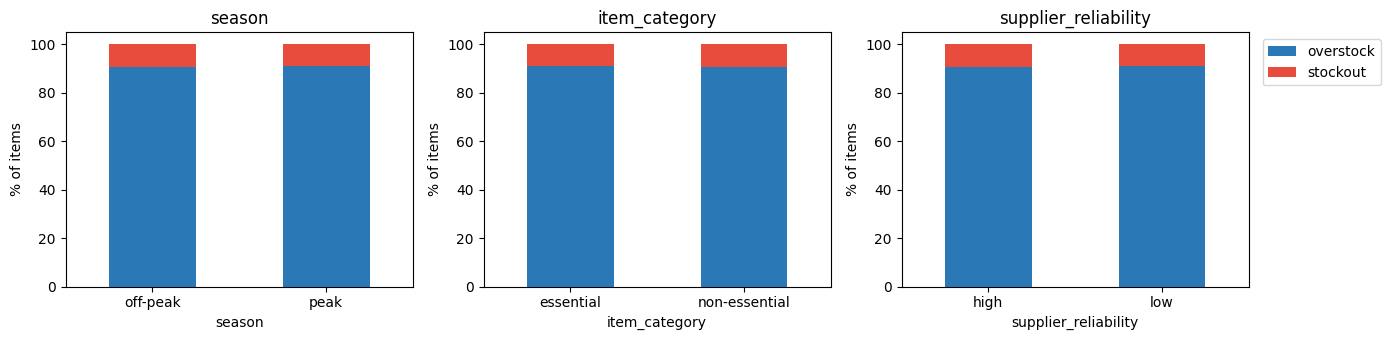

In [9]:
# Create 3 charts, one for each categorical column
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, col in zip(axes, cat_cols):

    # Calculate stock-status percentages for each category
    table = pd.crosstab(
        df[col],
        df["stock_status"],
        normalize="index"
    ) * 100

    # Draw the percentages as a stacked bar chart
    table.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        rot=0,
        color=[COLORS[c] for c in table.columns],
        legend=False
    )

    ax.set_title(col)
    ax.set_ylabel("% of items")

# Put the legend outside the last chart
axes[2].legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## 10. Check correlations

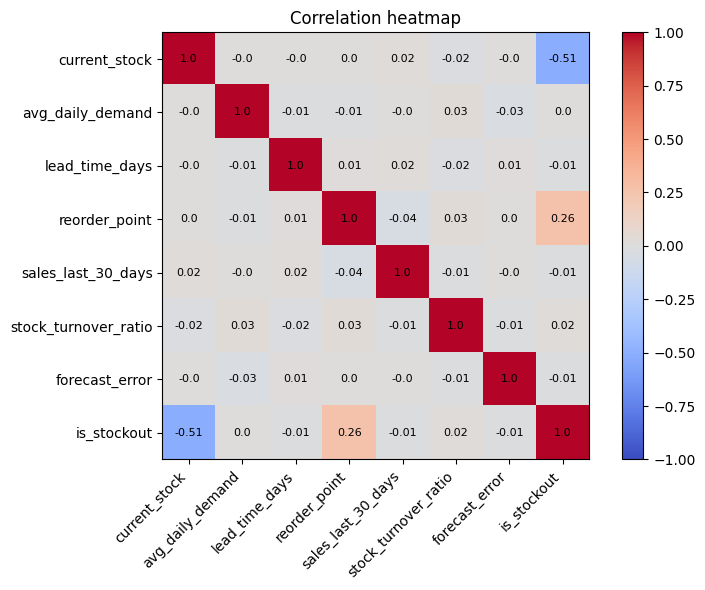

In [10]:
# Convert the target into numbers:
# stockout = 1, everything else (overstock) = 0
df["is_stockout"] = (
    df["stock_status"] == "stockout"
).astype(int)

# Calculate the correlation between numeric features and stockout
corr = df[numeric_cols + ["is_stockout"]].corr().round(2)

# Create the heatmap
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

# Add column names to the x-axis and y-axis
plt.xticks(
    range(len(corr)),
    corr.columns,
    rotation=45,
    ha="right"
)
plt.yticks(range(len(corr)), corr.columns)

# Write the correlation number inside every square
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            corr.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


## 11. Find the strongest relationships with stockout

In [11]:
# Show the correlation of every feature with the stockout target
# abs() means we sort by strength, whether the correlation is positive or negative
corr["is_stockout"].drop("is_stockout").sort_values(
    key=abs,
    ascending=False
)


current_stock          -0.51
reorder_point           0.26
stock_turnover_ratio    0.02
lead_time_days         -0.01
sales_last_30_days     -0.01
forecast_error         -0.01
avg_daily_demand        0.00
Name: is_stockout, dtype: float64

## 12. Create useful new features

In [ ]:
# Create new columns from existing columns.
# How many days the current stock can last
df['days_of_cover'] = (
    df['current_stock'] / df['avg_daily_demand']
)
# Expected demand while waiting for a new order
df['lead_time_demand'] = (
    df['avg_daily_demand'] * df['lead_time_days']
)
# Difference between current stock and the reorder point
df['stock_gap'] = (
    df['current_stock'] - df['reorder_point']
)
new_cols = [
    "days_of_cover",
    "lead_time_demand",
    "stock_gap"
]
# Compare the average of these new features by stock status
df.groupby("stock_status")[new_cols].mean().round(2).T


stock_status,overstock,stockout
days_of_cover,10.84,7.11
lead_time_demand,350.50,347.70
stock_gap,169.67,-53.83


## 13. Compare the new features

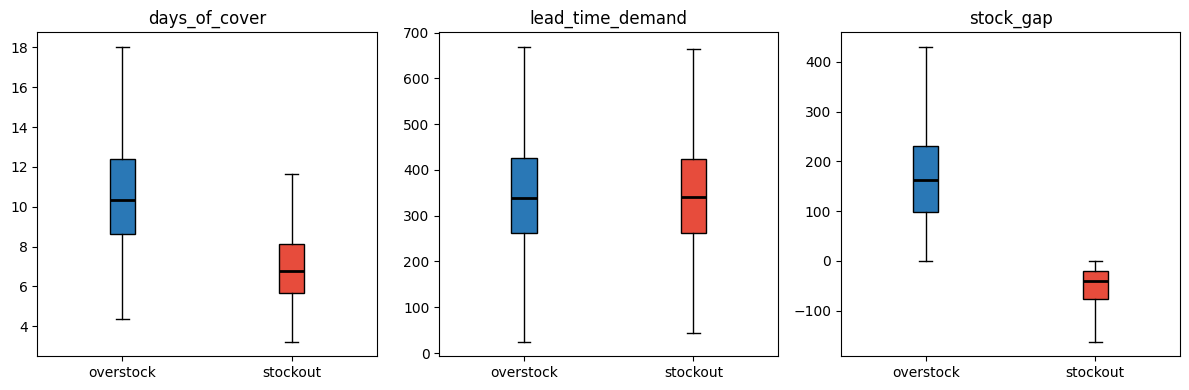

In [13]:
# Create 3 boxplots for the new features
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, new_cols):

    # Get the values separately for overstock and stockout
    groups = [
        df.loc[df["stock_status"] == s, col]
        for s in ["overstock", "stockout"]
    ]

    # Draw the boxplots
    box = ax.boxplot(
        groups,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 2}
    )

    # Apply the same colors used earlier
    for patch, s in zip(box["boxes"], ["overstock", "stockout"]):
        patch.set_facecolor(COLORS[s])

    ax.set_xticklabels(["overstock", "stockout"])
    ax.set_title(col)

plt.tight_layout()
plt.show()
